<a href="https://colab.research.google.com/github/santoshs0612/Foundational-Math-in-ML/blob/main/Comparing_SGD_and_BGD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparing the stochastic gradient decent and batch graidient decent



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

### Genrating synthetic data

In [ ]:
def generate_data(num_sampels):
  np.random.seed(42)
  X = np.random.rand(num_sampels,1) + 10 # Features
  true_m , true_c = 3 , 7 # True parameters
  y = true_m * X + true_c + np.random.rand(num_sampels,1)
  return X , y

### Mean Sqaure Error(Loss Function)

In [ ]:
def compute_loss(y_true,y_pred):
  return np.mean((y_true-y_pred)**2)

### Batch Gradient Decent

In [ ]:
def batch_gradient_descent(X,y,epochs,learning_rate=0.01):
  m , n = X.shape
  y = y.reshape(-1, 1)
  X = np.c_[np.ones((m,1)),X] # Adding Bias
  theta = np.random.randn(n+1,1)
  losses = []
  for epoch in range(epochs):
    y_pred = X.dot(theta)
    loss = compute_loss(y,y_pred)
    losses.append(loss)
    gradient = (1/m) * X.T.dot(y_pred-y)
    theta -= learning_rate * gradient
  return theta , losses


### Stochastic Gradient Decent

In [ ]:
def stochastic_gradient_descent(X,y,epochs,learning_rate=0.01):
  m,n = X.shape
  y = y.reshape(-1, 1)
  X = np.c_[np.ones((m,1)),X] # Added the Bias Term
  theta = np.random.randn(n+1,1)
  losses = []
  for epoch in range(epochs):
    random_index = np.random.randint(m)
    xi = X[random_index:random_index +1]
    yi = y[random_index:random_index +1]
    y_pred = xi.dot(theta)
    loss = compute_loss(yi,y_pred)
    losses.append(loss)
    gradient = 2 * xi.T.dot(y_pred-yi)
    theta -= learning_rate * gradient
  return theta , losses

### Comparing on Small and Large datasets

In [ ]:
small_data_size = 1000
large_data_size = 10000000
X_small , y_small = generate_data(small_data_size)
X_large , y_large = generate_data(large_data_size)

### Run Batch Gradient Decent

In [ ]:
# For Small Dataset
start_time = time.time()
batch_theta_small , batch_losses_small = batch_gradient_descent(X_small,y_small,epochs=50)
end_time = time.time()
batch_time_small = end_time - start_time

# For Large DataSet
start_time = time.time()
batch_theta_large , batch_losses_large = batch_gradient_descent(X_large,y_large,epochs=50)
end_time = time.time()
batch_time_large = end_time - start_time


### Run Stochastic Gradient Decent

In [ ]:
# For Small Dataset
start_time = time.time()
stochastic_theta_small , stochastic_losses_small = stochastic_gradient_descent(X_small,y_small,epochs=50)
end_time = time.time()
stochastic_time_small = end_time - start_time

#For large Dataset
start_time = time.time()
stochastic_theta_large , stochastic_losses_large = stochastic_gradient_descent(X_large,y_large,epochs=50)
end_time = time.time()
stochastic_time_large = end_time - start_time

### Printing Results


In [ ]:
print("Batch Gradient Descent:")
print(f"Small Dataset - Time: {batch_time_small:.4f} seconds , Loss: {batch_losses_small[-1]:.4f}")
print(f"Large Dataset - Time: {batch_time_large:.4f} seconds , Loss: {batch_losses_large[-1]:.4f}")
print("Stochastic Gradient Descent:")
print(f"Small Dataset - Time: {stochastic_time_small:.4f} seconds , Loss: {stochastic_losses_small[-1]:.4f}")
print(f"Large Dataset - Time: {stochastic_time_large:.4f} seconds , Loss: {stochastic_losses_large[-1]:.4f}")


Batch Gradient Descent:
Small Dataset - Time: 0.0035 seconds , Loss: 0.1125
Large Dataset - Time: 9.3241 seconds , Loss: 0.1120
Stochastic Gradient Descent:
Small Dataset - Time: 0.0054 seconds , Loss: 3159131240687.6094
Large Dataset - Time: 0.1013 seconds , Loss: 197976029415.1829


### Plot Losses


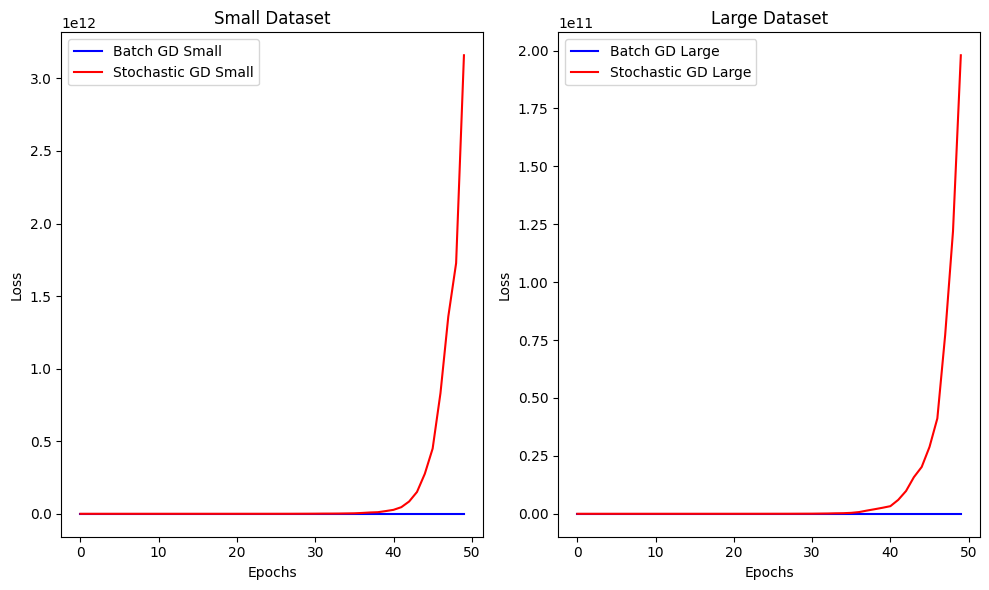

In [ ]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.plot(batch_losses_small,label = "Batch GD Small",color="blue")
plt.plot(stochastic_losses_small,label = "Stochastic GD Small",color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Small Dataset")

plt.subplot(1,2,2)
plt.plot(batch_losses_large,label = "Batch GD Large",color="blue")
plt.plot(stochastic_losses_large,label = "Stochastic GD Large",color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Large Dataset")

plt.tight_layout()
plt.show()